In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Mall Customers Segmentation.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 5)

Column Names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [10]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


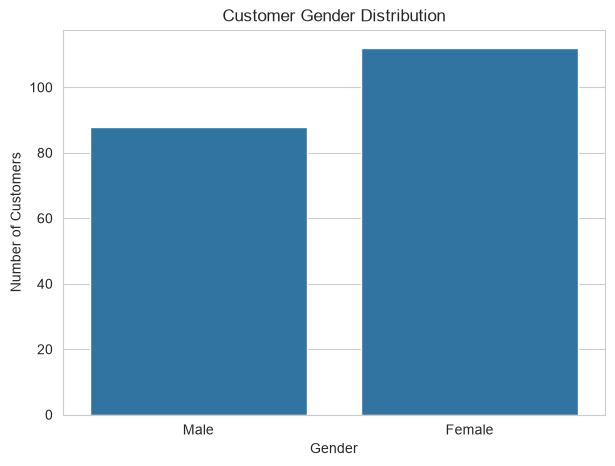

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

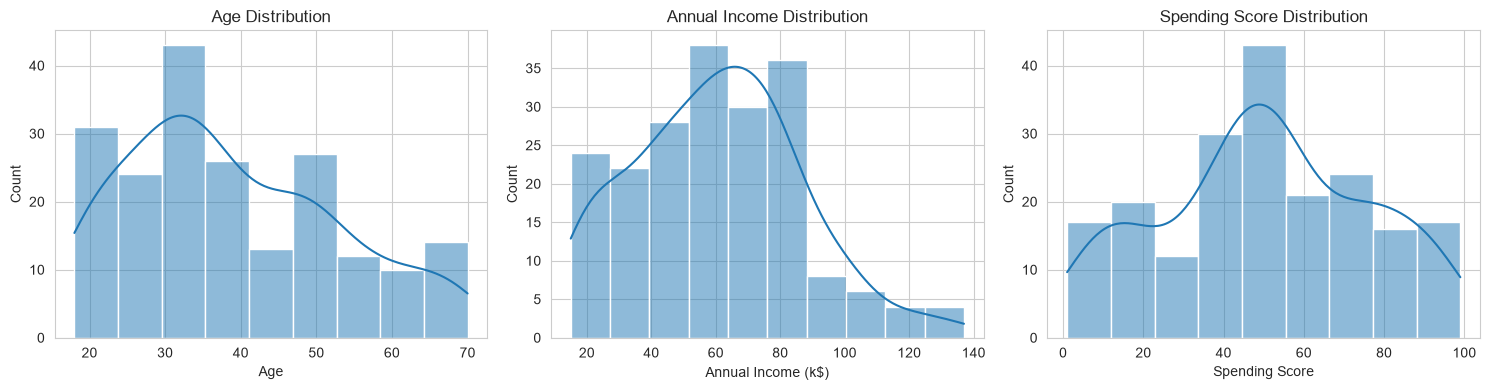

In [7]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")

plt.subplot(1, 3, 2)
sns.histplot(df["Annual Income (k$)"], kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")

plt.subplot(1, 3, 3)
sns.histplot(df["Spending Score (1-100)"], kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")

plt.tight_layout()
plt.show()

In [8]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [12]:
inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

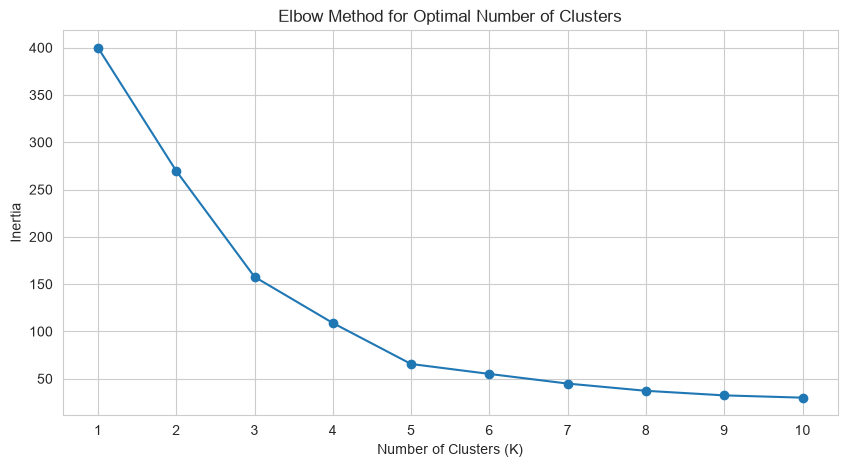

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [15]:
cluster_counts = df["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

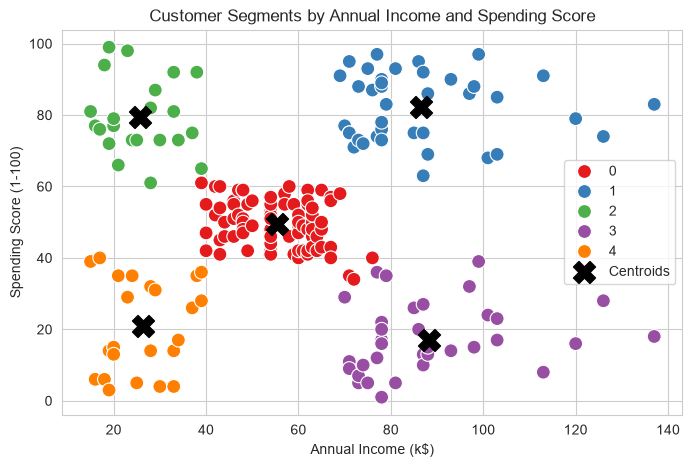

In [27]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

centers_scaled = kmeans.cluster_centers_

centers = scaler.inverse_transform(centers_scaled)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    color="black",
    label="Centroids"
)

plt.title("Customer Segments by Annual Income and Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.show()

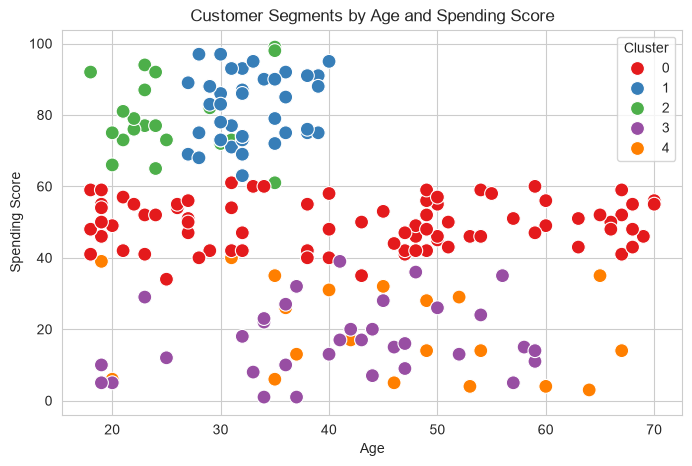

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segments by Age and Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.legend(title="Cluster")

plt.show()

In [18]:
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [19]:
cluster_profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

cluster_profile

,Customers,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


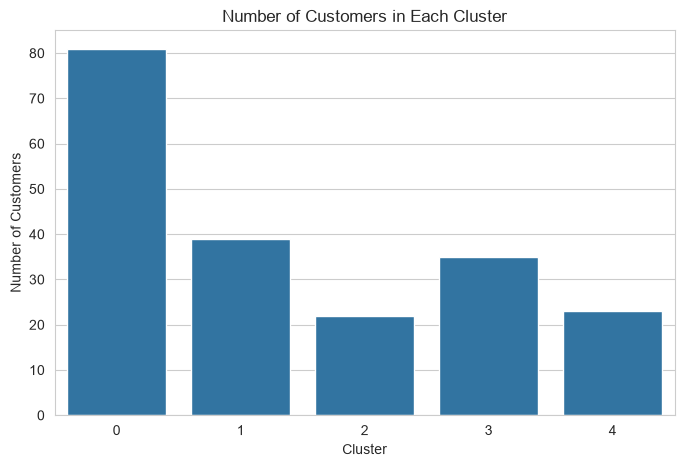

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

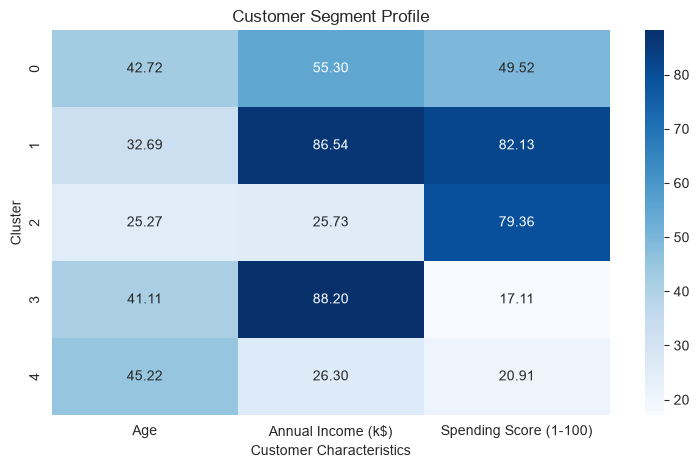

In [21]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    cluster_summary,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Customer Segment Profile")
plt.xlabel("Customer Characteristics")
plt.ylabel("Cluster")

plt.show()

In [31]:
cluster_profile = cluster_profile.copy()

income_median = df["Annual Income (k$)"].median()
spending_median = df["Spending Score (1-100)"].median()

def classify_cluster(row):

    income = row["Average_Income"]
    spending = row["Average_Spending"]

    if income >= income_median and spending >= spending_median:
        return "High Value Customers"

    elif income < income_median and spending >= spending_median:
        return "Young Big Spenders"

    elif income >= income_median and spending < spending_median:
        return "Untapped Potential"

    else:
        return "Moderate Engagement Customers"


cluster_profile["Customer Type"] = cluster_profile.apply(
    classify_cluster,
    axis=1
)

cluster_profile

,Customers,Average_Age,Average_Income,Average_Spending,Customer Type
Cluster,,,,,
0,81,42.72,55.30,49.52,Moderate Engagement Customers
1,39,32.69,86.54,82.13,High Value Customers
2,22,25.27,25.73,79.36,Young Big Spenders
3,35,41.11,88.20,17.11,Untapped Potential
4,23,45.22,26.30,20.91,Moderate Engagement Customers


In [34]:
final_profile = cluster_profile[
    [
        "Customers",
        "Average_Age",
        "Average_Income",
        "Average_Spending",
        "Customer Type"
    ]
].copy()

final_profile

,Customers,Average_Age,Average_Income,Average_Spending,Customer Type
Cluster,,,,,
0,81,42.72,55.30,49.52,Moderate Engagement Customers
1,39,32.69,86.54,82.13,High Value Customers
2,22,25.27,25.73,79.36,Young Big Spenders
3,35,41.11,88.20,17.11,Untapped Potential
4,23,45.22,26.30,20.91,Moderate Engagement Customers


In [35]:
recommendations = {
    "High Value Customers":
        "Prioritize loyalty programs, premium products, exclusive offers, and personalized promotions.",

    "Young Big Spenders":
        "Promote trendy and affordable products, student discounts, and social-media campaigns.",

    "Untapped Potential":
        "Use personalized promotions and targeted campaigns to increase engagement and spending.",

    "Moderate Engagement Customers":
    "Use loyalty rewards, personalized offers, and bundle promotions to increase spending."
}

final_profile["Marketing Recommendation"] = (
    final_profile["Customer Type"].map(recommendations)
)

final_profile

,Customers,Average_Age,Average_Income,Average_Spending,Customer Type,Marketing Recommendation
Cluster,,,,,,
0,81,42.72,55.30,49.52,Moderate Engagement Customers,"Use loyalty rewards, personalized offers, and ..."
1,39,32.69,86.54,82.13,High Value Customers,"Prioritize loyalty programs, premium products,..."
2,22,25.27,25.73,79.36,Young Big Spenders,"Promote trendy and affordable products, studen..."
3,35,41.11,88.20,17.11,Untapped Potential,Use personalized promotions and targeted campa...
4,23,45.22,26.30,20.91,Moderate Engagement Customers,"Use loyalty rewards, personalized offers, and ..."


In [36]:
print("CUSTOMER SEGMENTATION RESULTS")
print("=" * 60)

for cluster, row in final_profile.iterrows():

    print(f"\nCluster {cluster}")
    print("-" * 30)
    print(f"Customer Type: {row['Customer Type']}")
    print(f"Customers: {int(row['Customers'])}")
    print(f"Average Age: {row['Average_Age']:.2f}")
    print(f"Average Income: ${row['Average_Income']:.2f}k")
    print(f"Average Spending Score: {row['Average_Spending']:.2f}")
    print(f"Recommendation: {row['Marketing Recommendation']}")

CUSTOMER SEGMENTATION RESULTS

Cluster 0
------------------------------
Customer Type: Moderate Engagement Customers
Customers: 81
Average Age: 42.72
Average Income: $55.30k
Average Spending Score: 49.52
Recommendation: Use loyalty rewards, personalized offers, and bundle promotions to increase spending.

Cluster 1
------------------------------
Customer Type: High Value Customers
Customers: 39
Average Age: 32.69
Average Income: $86.54k
Average Spending Score: 82.13
Recommendation: Prioritize loyalty programs, premium products, exclusive offers, and personalized promotions.

Cluster 2
------------------------------
Customer Type: Young Big Spenders
Customers: 22
Average Age: 25.27
Average Income: $25.73k
Average Spending Score: 79.36
Recommendation: Promote trendy and affordable products, student discounts, and social-media campaigns.

Cluster 3
------------------------------
Customer Type: Untapped Potential
Customers: 35
Average Age: 41.11
Average Income: $88.20k
Average Spending Sco

## Conclusion

The K-Means clustering analysis successfully segmented the 200 customers into five distinct groups based mainly on Annual Income and Spending Score. The Elbow Method indicated that five clusters provided a suitable balance between cluster separation and model simplicity.

The results show clear differences in customer behaviour:

- **Cluster 0** contains the largest group, with 81 customers. These customers have a moderate average income of $55.30k and a medium spending score of 49.52. They represent the general customer group and could be encouraged to increase their spending through targeted promotions and loyalty offers.

- **Cluster 1** contains 39 customers with a high average income of $86.54k and a high spending score of 82.13. This is the most valuable customer segment. The company should focus on loyalty programs, premium products, exclusive offers, and personalised marketing.

- **Cluster 2** contains 22 customers with a low average income of $25.73k but a high spending score of 79.36. These customers are relatively young, with an average age of 25.27 years, and show strong spending behaviour despite lower income. Affordable products, student-focused promotions, and social media campaigns could be effective for this group.

- **Cluster 3** contains 35 customers with a high average income of $88.20k but a very low spending score of 17.11. This group represents an important opportunity because customers have strong purchasing capacity but currently spend very little. Personalised offers and targeted campaigns could be used to increase their engagement.

- **Cluster 4** contains 23 customers with a low average income of $26.30k and a low spending score of 20.91. These customers show relatively low purchasing activity. The company should use cost-effective promotions and incentives rather than allocating a large marketing budget to this segment.

Overall, the analysis demonstrates that customers should not be treated as one homogeneous group. Each segment has different income levels and spending behaviours, so the company can use these insights to develop more targeted and cost-effective marketing strategies. In particular, Cluster 1 should receive the highest priority because of its combination of high income and high spending, while Cluster 3 represents a strong opportunity for future growth.